# CSV to Video Alignment Debug Notebook

This notebook helps verify whether rows in `lekiwi_green_block.csv` align with the correct frames in `file-000.mp4`.

It is designed for manual debugging rather than automatic alignment. The workflow supports:

- episode-local `frame_index`
- a candidate `start_frame` for each episode inside the concatenated video
- an optional `stride` / `frames_per_step` in case the video frame rate differs from the logging rate
- robust CSV schema handling, including packed `action` arrays or separate velocity columns

## 1. Import Dependencies

Import the libraries used for CSV parsing, video access, plotting, and lightweight data structures.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Any, Optional
import math
import re

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

## 2. Define Configuration and Inputs

Set the dataset paths, default manual alignment parameters, and output directory. These are the main values you will edit during manual debugging.

In [2]:
WORKSPACE_DIR = Path('/Users/josephxu/Desktop/lekiwi')
CSV_PATH = WORKSPACE_DIR / 'lekiwi_green_block.csv'
VIDEO_PATH = WORKSPACE_DIR / 'file-000.mp4'
OUTPUT_DIR = WORKSPACE_DIR / 'alignment_debug'

DEFAULT_EPISODE_INDEX = 0
DEFAULT_CANDIDATE_START_FRAME = 0
DEFAULT_STRIDE = 1.0
DEFAULT_SAVE_OUTPUTS = True
DEFAULT_SHOW_INLINE = True

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'CSV path: {CSV_PATH}')
print(f'Video path: {VIDEO_PATH}')
print(f'Output directory: {OUTPUT_DIR}')

CSV path: /Users/josephxu/Desktop/lekiwi/lekiwi_green_block.csv
Video path: /Users/josephxu/Desktop/lekiwi/file-000.mp4
Output directory: /Users/josephxu/Desktop/lekiwi/alignment_debug


## 3. Implement Core Data Structures

These small data structures keep the CSV schema and video metadata explicit, which makes the later helper functions easier to reason about.

In [3]:
@dataclass
class CSVSchema:
    """Tracks which source columns were detected and how velocity values were derived."""

    episode_col: str
    frame_col: str
    timestamp_col: Optional[str]
    x_vel_col: Optional[str]
    y_vel_col: Optional[str]
    theta_vel_col: Optional[str]
    action_col: Optional[str]


@dataclass
class VideoMetadata:
    """Stores the video properties needed for frame lookup and diagnostics."""

    fps: float
    frame_count: int
    duration_seconds: float
    width: int
    height: int

## 4. Build Main Processing Functions

The helpers below do four jobs:

- normalize the CSV schema and velocity columns
- compute dataset and per-episode diagnostics
- retrieve frames from the concatenated video
- export overlaid samples for manual alignment inspection

In [4]:
def normalize_name(name: str) -> str:
    """Normalizes a column name so exact and fuzzy matching are easier."""

    return re.sub(r'[^a-z0-9]+', '', str(name).strip().lower())


def find_column(columns: list[str], exact: list[str], contains: list[str]) -> Optional[str]:
    """Finds the best matching column using exact-name-first and substring fallbacks."""

    normalized = {column: normalize_name(column) for column in columns}
    exact_normalized = [normalize_name(value) for value in exact]
    contains_normalized = [normalize_name(value) for value in contains]

    for target in exact_normalized:
        for column, normalized_name in normalized.items():
            if normalized_name == target:
                return column

    for target in contains_normalized:
        for column, normalized_name in normalized.items():
            if target in normalized_name:
                return column

    return None


def parse_array_like(value: Any) -> np.ndarray:
    """Parses array-like strings such as '[0. 0. 0.]' into a numeric numpy array."""

    if isinstance(value, np.ndarray):
        return value.astype(float)

    if isinstance(value, (list, tuple)):
        return np.asarray(value, dtype=float)

    if value is None or (isinstance(value, float) and math.isnan(value)):
        return np.asarray([], dtype=float)

    text = str(value).strip()
    if not text:
        return np.asarray([], dtype=float)

    if text.startswith('[') and text.endswith(']'):
        text = text[1:-1]

    text = text.replace(',', ' ')
    parsed = np.fromstring(text, sep=' ')
    return parsed.astype(float)


def detect_csv_schema(df: pd.DataFrame) -> CSVSchema:
    """Detects the episode, frame, timestamp, and velocity columns even if names vary slightly."""

    columns = list(df.columns)

    episode_col = find_column(columns, exact=['episode_index'], contains=['episodeindex', 'episode'])
    frame_col = find_column(columns, exact=['frame_index'], contains=['frameindex', 'frame'])
    timestamp_col = find_column(columns, exact=['timestamp'], contains=['timestamp', 'time'])

    x_vel_col = find_column(columns, exact=['action.x.vel', 'x_vel'], contains=['xvel', 'actionxvel'])
    y_vel_col = find_column(columns, exact=['action.y.vel', 'y_vel'], contains=['yvel', 'actionyvel'])
    theta_vel_col = find_column(columns, exact=['action.theta.vel', 'theta_vel'], contains=['thetavel', 'angularvel', 'yawvel'])
    action_col = find_column(columns, exact=['action'], contains=['action'])

    if episode_col is None:
        raise ValueError('Could not find an episode index column.')
    if frame_col is None:
        raise ValueError('Could not find a frame index column.')

    return CSVSchema(
        episode_col=episode_col,
        frame_col=frame_col,
        timestamp_col=timestamp_col,
        x_vel_col=x_vel_col,
        y_vel_col=y_vel_col,
        theta_vel_col=theta_vel_col,
        action_col=action_col,
    )


def load_alignment_dataframe(csv_path: Path) -> tuple[pd.DataFrame, CSVSchema]:
    """Loads the CSV, normalizes key columns, and derives velocity signals for plotting and overlays."""

    df = pd.read_csv(csv_path)
    schema = detect_csv_schema(df)

    df = df.copy()
    df['episode_index_normalized'] = pd.to_numeric(df[schema.episode_col], errors='coerce').astype('Int64')
    df['local_frame_index'] = pd.to_numeric(df[schema.frame_col], errors='coerce').astype('Int64')

    if schema.timestamp_col is not None:
        df['timestamp_normalized'] = pd.to_numeric(df[schema.timestamp_col], errors='coerce')
    else:
        df['timestamp_normalized'] = np.nan

    used_direct_velocity_columns = all(
        column is not None for column in [schema.x_vel_col, schema.y_vel_col, schema.theta_vel_col]
    )

    if used_direct_velocity_columns:
        df['x_vel'] = pd.to_numeric(df[schema.x_vel_col], errors='coerce')
        df['y_vel'] = pd.to_numeric(df[schema.y_vel_col], errors='coerce')
        df['theta_vel'] = pd.to_numeric(df[schema.theta_vel_col], errors='coerce')
    elif schema.action_col is not None:
        action_vectors = df[schema.action_col].apply(parse_array_like)
        df['x_vel'] = action_vectors.apply(lambda values: values[0] if len(values) > 0 else np.nan)
        df['y_vel'] = action_vectors.apply(lambda values: values[1] if len(values) > 1 else np.nan)
        df['theta_vel'] = action_vectors.apply(lambda values: values[2] if len(values) > 2 else np.nan)
    else:
        raise ValueError('Could not find separate velocity columns or a packed action column.')

    df['planar_speed'] = np.sqrt(df['x_vel'].fillna(0.0) ** 2 + df['y_vel'].fillna(0.0) ** 2)
    df = df.sort_values(['episode_index_normalized', 'local_frame_index']).reset_index(drop=True)

    return df, schema


def build_episode_summary(df: pd.DataFrame) -> pd.DataFrame:
    """Builds the per-episode summary table used for diagnostics and quick inspection."""

    summary = (
        df.groupby('episode_index_normalized', dropna=False)
        .agg(
            num_rows=('local_frame_index', 'size'),
            min_frame_index=('local_frame_index', 'min'),
            max_frame_index=('local_frame_index', 'max'),
            min_timestamp=('timestamp_normalized', 'min'),
            max_timestamp=('timestamp_normalized', 'max'),
        )
        .reset_index()
        .rename(columns={'episode_index_normalized': 'episode_index'})
    )

    if summary['min_timestamp'].isna().all() and summary['max_timestamp'].isna().all():
        summary = summary.drop(columns=['min_timestamp', 'max_timestamp'])
    else:
        summary['duration'] = summary['max_timestamp'] - summary['min_timestamp']

    return summary


def print_dataset_diagnostics(df: pd.DataFrame, episode_summary: pd.DataFrame, metadata: VideoMetadata) -> None:
    """Prints the core CSV and video diagnostics needed before manual alignment testing."""

    print('Dataset diagnostics')
    print('-' * 80)
    print(f'Total CSV rows: {len(df):,}')
    print(f'Unique episode count: {df["episode_index_normalized"].nunique(dropna=True):,}')
    print('\nPer-episode row count:')
    print(df.groupby('episode_index_normalized')['local_frame_index'].size().to_string())
    print('\nPer-episode min/max frame_index:')
    print(
        df.groupby('episode_index_normalized')['local_frame_index']
        .agg(['min', 'max'])
        .rename(columns={'min': 'min_frame_index', 'max': 'max_frame_index'})
        .to_string()
    )
    print('\nVideo diagnostics:')
    print(f'Video FPS: {metadata.fps:.4f}')
    print(f'Total video frame count: {metadata.frame_count:,}')
    print(f'Total video duration: {metadata.duration_seconds:.2f} seconds')
    print(f'Video resolution: {metadata.width}x{metadata.height}')
    print('\nEpisode summary preview:')
    display(episode_summary.head())

In [5]:
def load_video_metadata(video_path: Path) -> VideoMetadata:
    """Loads video metadata once so later frame lookups can validate bounds."""

    capture = cv2.VideoCapture(str(video_path))
    if not capture.isOpened():
        raise ValueError(f'Could not open video: {video_path}')

    fps = float(capture.get(cv2.CAP_PROP_FPS) or 0.0)
    frame_count = int(capture.get(cv2.CAP_PROP_FRAME_COUNT) or 0)
    width = int(capture.get(cv2.CAP_PROP_FRAME_WIDTH) or 0)
    height = int(capture.get(cv2.CAP_PROP_FRAME_HEIGHT) or 0)
    capture.release()

    duration_seconds = frame_count / fps if fps > 0 else float('nan')
    return VideoMetadata(
        fps=fps,
        frame_count=frame_count,
        duration_seconds=duration_seconds,
        width=width,
        height=height,
    )


def get_frame_by_global_index(video_path: Path, global_frame: int) -> np.ndarray:
    """Retrieves a frame from the concatenated video by global frame number."""

    if global_frame < 0:
        raise ValueError(f'Global frame must be non-negative, got {global_frame}.')

    capture = cv2.VideoCapture(str(video_path))
    if not capture.isOpened():
        raise ValueError(f'Could not open video: {video_path}')

    capture.set(cv2.CAP_PROP_POS_FRAMES, float(global_frame))
    success, frame_bgr = capture.read()
    capture.release()

    if not success or frame_bgr is None:
        raise ValueError(f'Could not read global frame {global_frame}.')

    return frame_bgr


def compute_global_frame(candidate_start_frame: float, local_frame_index: int, stride: float = 1.0) -> int:
    """Maps an episode-local frame index into the concatenated video using start frame and stride."""

    return int(round(candidate_start_frame + stride * local_frame_index))


def get_episode_dataframe(df: pd.DataFrame, episode_index: int) -> pd.DataFrame:
    """Returns one episode sorted by local frame index for plotting and anchor sampling."""

    episode_df = df[df['episode_index_normalized'] == episode_index].copy()
    if episode_df.empty:
        raise ValueError(f'No rows found for episode_index={episode_index}.')
    return episode_df.sort_values('local_frame_index').reset_index(drop=True)


def get_episode_row(df: pd.DataFrame, episode_index: int, local_frame_index: int) -> pd.Series:
    """Fetches the CSV row for a specific episode-local frame index."""

    episode_df = get_episode_dataframe(df, episode_index)
    matching_rows = episode_df[episode_df['local_frame_index'] == local_frame_index]
    if matching_rows.empty:
        raise ValueError(
            f'No row found for episode_index={episode_index}, local_frame_index={local_frame_index}.'
        )
    return matching_rows.iloc[0]


def get_aligned_video_frame(
    df: pd.DataFrame,
    video_path: Path,
    episode_index: int,
    local_frame_index: int,
    candidate_start_frame: float,
    stride: float = 1.0,
) -> tuple[pd.Series, int, np.ndarray]:
    """Combines CSV lookup and frame mapping so one call retrieves the aligned video frame."""

    row = get_episode_row(df, episode_index, local_frame_index)
    global_frame = compute_global_frame(candidate_start_frame, local_frame_index, stride=stride)
    frame_bgr = get_frame_by_global_index(video_path, global_frame)
    return row, global_frame, frame_bgr


def make_overlay_text(row: pd.Series, episode_index: int, local_frame_index: int, global_frame: int) -> list[str]:
    """Builds the text overlay used to inspect whether the sampled frame matches the logged action."""

    return [
        f'episode_index: {episode_index}',
        f'local_frame_index: {local_frame_index}',
        f'global_frame: {global_frame}',
        f'x_vel: {row["x_vel"]:.4f}',
        f'y_vel: {row["y_vel"]:.4f}',
        f'theta_vel: {row["theta_vel"]:.4f}',
    ]


def overlay_text_on_frame(frame_bgr: np.ndarray, lines: list[str]) -> np.ndarray:
    """Draws debug text onto a frame so saved images preserve the alignment context."""

    output = frame_bgr.copy()
    origin_x = 20
    origin_y = 35
    line_height = 30

    for line_number, line in enumerate(lines):
        y = origin_y + line_number * line_height
        cv2.putText(
            output,
            line,
            (origin_x, y),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0, 0, 0),
            4,
            cv2.LINE_AA,
        )
        cv2.putText(
            output,
            line,
            (origin_x, y),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (255, 255, 255),
            2,
            cv2.LINE_AA,
        )

    return output


def show_frame_inline(frame_bgr: np.ndarray, title: str) -> None:
    """Displays one frame inline in the notebook using matplotlib."""

    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 6))
    plt.imshow(frame_rgb)
    plt.title(title)
    plt.axis('off')
    plt.show()


def sanitize_stride_for_filename(stride: float) -> str:
    """Makes stride safe to place inside a filename."""

    return str(stride).replace('.', 'p')


def save_debug_frame(
    frame_bgr: np.ndarray,
    output_dir: Path,
    episode_index: int,
    local_frame_index: int,
    global_frame: int,
    candidate_start_frame: float,
    stride: float,
) -> Path:
    """Saves one debug image to disk so candidate alignments can be compared outside the notebook."""

    output_dir.mkdir(parents=True, exist_ok=True)
    file_name = (
        f'episode_{episode_index:03d}'
        f'_local_{int(local_frame_index):06d}'
        f'_global_{int(global_frame):06d}'
        f'_start_{int(round(candidate_start_frame)):06d}'
        f'_stride_{sanitize_stride_for_filename(stride)}.png'
    )
    output_path = output_dir / file_name
    success = cv2.imwrite(str(output_path), frame_bgr)
    if not success:
        raise ValueError(f'Failed to save frame to {output_path}')
    return output_path


def render_alignment_samples(
    df: pd.DataFrame,
    video_path: Path,
    episode_index: int,
    sampled_local_frame_indices: list[int],
    candidate_start_frame: float,
    stride: float = 1.0,
    output_dir: Optional[Path] = None,
    save_outputs: bool = True,
    show_inline: bool = True,
) -> list[Path]:
    """Exports or displays sampled frames so you can visually test one candidate alignment."""

    saved_paths: list[Path] = []

    for local_frame_index in sampled_local_frame_indices:
        row, global_frame, frame_bgr = get_aligned_video_frame(
            df=df,
            video_path=video_path,
            episode_index=episode_index,
            local_frame_index=int(local_frame_index),
            candidate_start_frame=candidate_start_frame,
            stride=stride,
        )
        overlay_lines = make_overlay_text(row, episode_index, int(local_frame_index), global_frame)
        annotated_frame = overlay_text_on_frame(frame_bgr, overlay_lines)

        if save_outputs and output_dir is not None:
            saved_path = save_debug_frame(
                frame_bgr=annotated_frame,
                output_dir=output_dir,
                episode_index=episode_index,
                local_frame_index=int(local_frame_index),
                global_frame=global_frame,
                candidate_start_frame=candidate_start_frame,
                stride=stride,
            )
            saved_paths.append(saved_path)

        if show_inline:
            title = (
                f'episode={episode_index}, local={int(local_frame_index)}, '
                f'global={global_frame}, stride={stride}'
            )
            show_frame_inline(annotated_frame, title)

    return saved_paths


def sample_anchor_local_frame_indices(episode_df: pd.DataFrame) -> list[int]:
    """Samples first, 25%, 50%, 75%, and last local indices for one episode."""

    local_indices = episode_df['local_frame_index'].dropna().astype(int).tolist()
    if not local_indices:
        raise ValueError('Episode has no valid local frame indices.')

    positions = [0.0, 0.25, 0.5, 0.75, 1.0]
    anchors: list[int] = []
    last_position = len(local_indices) - 1

    for position in positions:
        anchor_position = int(round(position * last_position))
        anchors.append(local_indices[anchor_position])

    return sorted(set(anchors))


def export_anchor_frames(
    df: pd.DataFrame,
    video_path: Path,
    episode_index: int,
    candidate_start_frame: float,
    stride: float = 1.0,
    output_dir: Optional[Path] = None,
    save_outputs: bool = True,
    show_inline: bool = True,
) -> tuple[list[int], list[Path]]:
    """Exports the standard anchor points used to check whether an alignment stays consistent across an episode."""

    episode_df = get_episode_dataframe(df, episode_index)
    anchors = sample_anchor_local_frame_indices(episode_df)
    saved_paths = render_alignment_samples(
        df=df,
        video_path=video_path,
        episode_index=episode_index,
        sampled_local_frame_indices=anchors,
        candidate_start_frame=candidate_start_frame,
        stride=stride,
        output_dir=output_dir,
        save_outputs=save_outputs,
        show_inline=show_inline,
    )
    return anchors, saved_paths


def plot_episode_velocities(df: pd.DataFrame, episode_index: int) -> pd.DataFrame:
    """Plots the logged velocities so visible motion in the video can be compared against the CSV signal."""

    episode_df = get_episode_dataframe(df, episode_index)

    plt.figure(figsize=(12, 6))
    plt.plot(episode_df['local_frame_index'], episode_df['x_vel'], label='x_vel')
    plt.plot(episode_df['local_frame_index'], episode_df['y_vel'], label='y_vel')
    plt.plot(episode_df['local_frame_index'], episode_df['theta_vel'], label='theta_vel')
    plt.plot(episode_df['local_frame_index'], episode_df['planar_speed'], label='planar_speed')
    plt.xlabel('local_frame_index')
    plt.ylabel('value')
    plt.title(f'Episode {episode_index} velocity signals')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return episode_df

## 5. Run the Initial Workflow

This section loads the CSV and MP4, prints diagnostics, and builds the per-episode summary table you can inspect before trying candidate alignments.

In [6]:
alignment_df, csv_schema = load_alignment_dataframe(CSV_PATH)
video_metadata = load_video_metadata(VIDEO_PATH)
episode_summary = build_episode_summary(alignment_df)

print('Detected CSV schema:')
print(csv_schema)
print()
print_dataset_diagnostics(alignment_df, episode_summary, video_metadata)

display(episode_summary)

Detected CSV schema:
CSVSchema(episode_col='episode_index', frame_col='frame_index', timestamp_col='timestamp', x_vel_col=None, y_vel_col=None, theta_vel_col=None, action_col='action')

Dataset diagnostics
--------------------------------------------------------------------------------
Total CSV rows: 19,793
Unique episode count: 50

Per-episode row count:
episode_index_normalized
0     598
1     320
2     299
3     598
4     598
5     335
6     225
7     515
8     598
9     256
10    391
11    598
12    360
13    359
14    395
15    373
16    360
17    413
18    242
19    351
20    598
21    270
22    312
23    398
24    290
25    509
26    388
27    385
28    260
29    190
30    359
31    598
32    560
33    502
34    507
35    498
36    399
37    393
38    465
39    507
40    254
41    356
42    270
43    321
44    259
45    260
46    491
47    288
48    210
49    512

Per-episode min/max frame_index:
                          min_frame_index  max_frame_index
episode_index_normalize

,episode_index,num_rows,min_frame_index,max_frame_index,min_timestamp,max_timestamp,duration
0,0,598,0,597,0.0,19.900000,19.900000
1,1,320,0,319,0.0,10.633333,10.633333
2,2,299,0,298,0.0,9.933333,9.933333
3,3,598,0,597,0.0,19.900000,19.900000
4,4,598,0,597,0.0,19.900000,19.900000


,episode_index,num_rows,min_frame_index,max_frame_index,min_timestamp,max_timestamp,duration
0,0,598,0,597,0.0,19.900000,19.900000
1,1,320,0,319,0.0,10.633333,10.633333
2,2,299,0,298,0.0,9.933333,9.933333
3,3,598,0,597,0.0,19.900000,19.900000
4,4,598,0,597,0.0,19.900000,19.900000
5,5,335,0,334,0.0,11.133333,11.133333
6,6,225,0,224,0.0,7.466667,7.466667
7,7,515,0,514,0.0,17.133333,17.133333
8,8,598,0,597,0.0,19.900000,19.900000
9,9,256,0,255,0.0,8.500000,8.500000


## 6. Validate Outputs with Simple Tests

These lightweight checks confirm that the parsed dataframe and alignment helpers are behaving sensibly before you spend time on visual inspection.

In [7]:
assert len(alignment_df) > 0, 'The alignment dataframe is empty.'
assert 'episode_index' in episode_summary.columns, 'Episode summary is missing episode_index.'
assert 'num_rows' in episode_summary.columns, 'Episode summary is missing num_rows.'
assert compute_global_frame(100, 5, 1.0) == 105, 'Global frame mapping failed for stride=1.0.'
assert compute_global_frame(100, 4, 1.5) == 106, 'Global frame mapping failed for non-unit stride.'

first_episode = int(episode_summary['episode_index'].dropna().iloc[0])
first_episode_df = get_episode_dataframe(alignment_df, first_episode)
first_local_frame = int(first_episode_df['local_frame_index'].iloc[0])
first_row = get_episode_row(alignment_df, first_episode, first_local_frame)

assert int(first_row['episode_index_normalized']) == first_episode
assert int(first_row['local_frame_index']) == first_local_frame
assert {'x_vel', 'y_vel', 'theta_vel', 'planar_speed'}.issubset(alignment_df.columns)

print('Basic validation checks passed.')

Basic validation checks passed.


## 7. Add Basic Error Handling and Logging

Edit the values below to test one candidate alignment. The cell plots the episode velocities, samples anchor points, and either saves or shows the overlaid frames.

This is the main cell you will rerun while adjusting `episode_index`, `candidate_start_frame`, and `stride`.

Running manual alignment check for episode=0, start_frame=0, stride=1.0


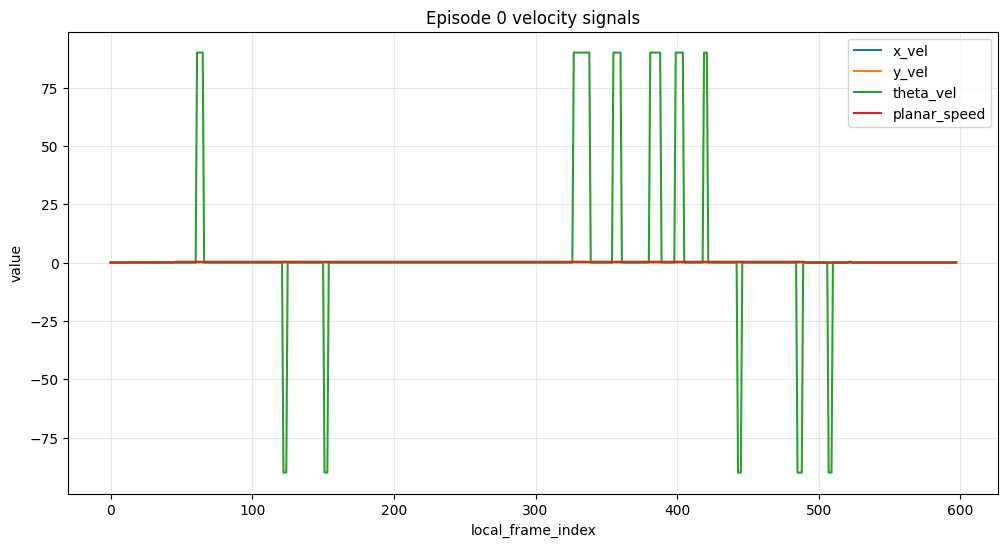

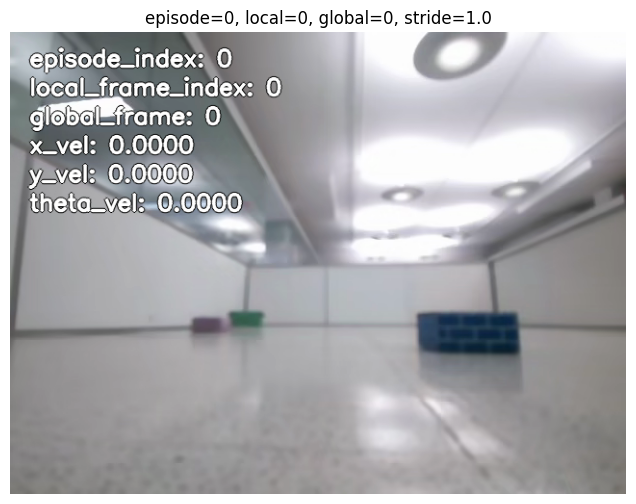

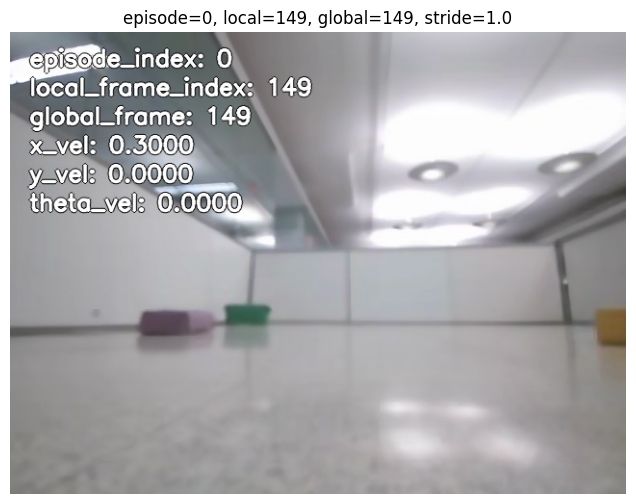

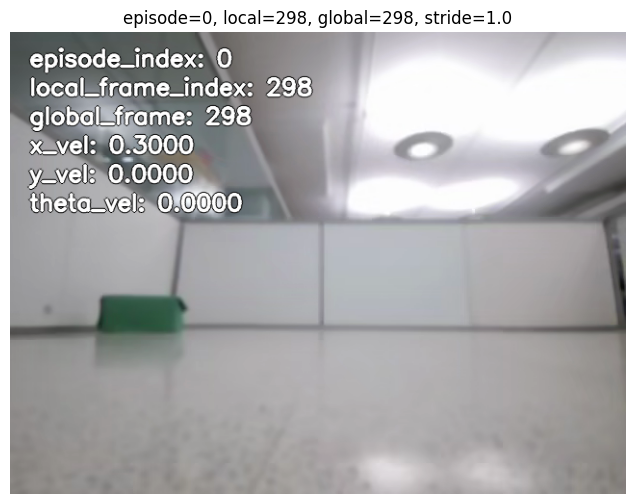

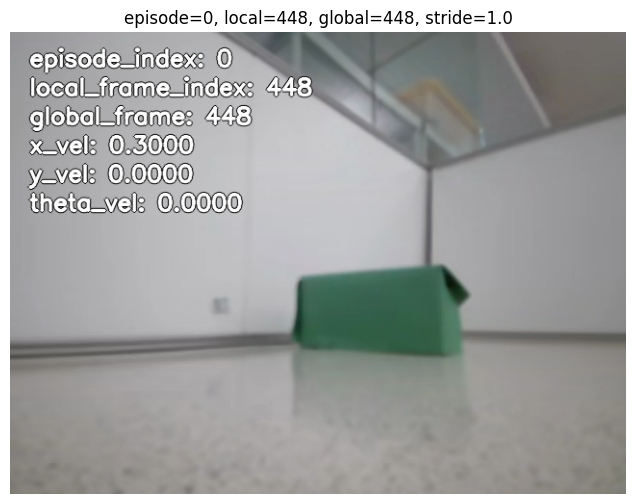

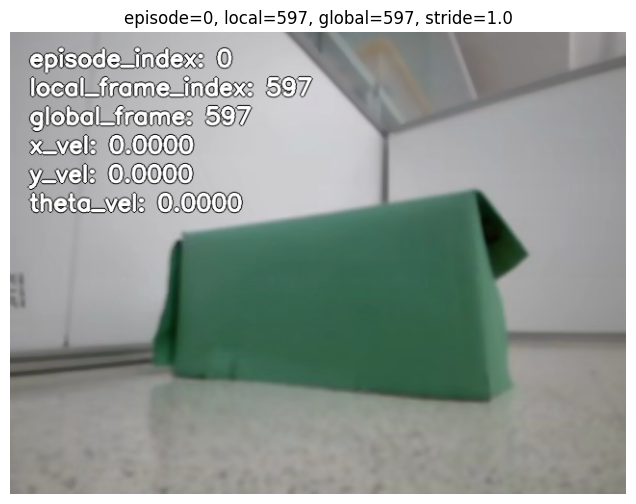

Anchor local frame indices: [0, 149, 298, 448, 597]
Saved debug frames:
/Users/josephxu/Desktop/lekiwi/alignment_debug/episode_000_local_000000_global_000000_start_000000_stride_1p0.png
/Users/josephxu/Desktop/lekiwi/alignment_debug/episode_000_local_000149_global_000149_start_000000_stride_1p0.png
/Users/josephxu/Desktop/lekiwi/alignment_debug/episode_000_local_000298_global_000298_start_000000_stride_1p0.png
/Users/josephxu/Desktop/lekiwi/alignment_debug/episode_000_local_000448_global_000448_start_000000_stride_1p0.png
/Users/josephxu/Desktop/lekiwi/alignment_debug/episode_000_local_000597_global_000597_start_000000_stride_1p0.png


In [8]:
episode_index = DEFAULT_EPISODE_INDEX
candidate_start_frame = DEFAULT_CANDIDATE_START_FRAME
stride = DEFAULT_STRIDE
save_outputs = DEFAULT_SAVE_OUTPUTS
show_inline = DEFAULT_SHOW_INLINE
output_dir = OUTPUT_DIR

try:
    print(
        f'Running manual alignment check for episode={episode_index}, '
        f'start_frame={candidate_start_frame}, stride={stride}'
    )

    episode_df = plot_episode_velocities(alignment_df, episode_index)
    anchor_local_indices, saved_paths = export_anchor_frames(
        df=alignment_df,
        video_path=VIDEO_PATH,
        episode_index=episode_index,
        candidate_start_frame=candidate_start_frame,
        stride=stride,
        output_dir=output_dir,
        save_outputs=save_outputs,
        show_inline=show_inline,
    )

    print(f'Anchor local frame indices: {anchor_local_indices}')
    if saved_paths:
        print('Saved debug frames:')
        for path in saved_paths:
            print(path)
except Exception as exc:
    print(f'Alignment debug run failed: {exc}')

## Usage Notes

Manual workflow:

1. Run all cells once to load the CSV, inspect the summary table, and confirm the video metadata.
2. Choose one `episode_index` from the summary table.
3. Set a candidate `candidate_start_frame` for where that episode begins in the concatenated MP4.
4. Start with `stride = 1.0`, then rerun the final cell.
5. Inspect the saved frames in `alignment_debug` and compare them with the velocity plot.
6. If early samples look correct but later ones drift, adjust `stride` slightly above or below `1.0`.
7. If the whole episode looks uniformly shifted, adjust `candidate_start_frame` instead.

Concrete visual sanity checks:

- Large `theta_vel` should coincide with visible turning.
- Near-zero planar speed should look like a pause or minimal translation.
- Sustained translational motion should match visible movement in the scene.
- The last anchor frame should look like a plausible end-of-episode state rather than a random mid-episode frame.
- If a candidate alignment is wrong, the anchor frames usually fail consistently or drift progressively across the episode.

Clean refactor suggestion:

If this notebook becomes part of a repeated workflow, move the reusable helpers into a small Python module such as `alignment_utils.py`, and keep the notebook focused on configuration, plotting, and manual review.